# Import Statements

In [10]:
import pickle
import numpy as np
import pandas as pd

In [11]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

In [12]:

from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


In [13]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [14]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [15]:
import tqdm as notebook_tqdm
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [16]:
from platform import python_version

print(python_version())


3.10.12


In [17]:
print(np.__version__)

1.26.3


# Define all functions

In [18]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}

# set parameter space for LASSO

elasticnet_space = {
    'alpha': Real(1e-3, 1.0, 'log-uniform'),
    'l1_ratio': Real(0.1, 0.99, 'uniform')
}

In [19]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [20]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

def bayesian_elasticnet_search(X, y, elasticnet_space):
    elasticnet = ElasticNet(max_iter=100000)
    elasticnet_bayes_search = BayesSearchCV(
        estimator=elasticnet,
        search_spaces=elasticnet_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=2,
        n_jobs=-1
)
    elasticnet_bayes_search.fit(X, y)
    
    print("Best ElasticNet hyperparameters:", elasticnet_bayes_search.best_params_)
    
    best_params = elasticnet_bayes_search.best_params_
    best_elasticnet = ElasticNet(**best_params)

    return best_elasticnet
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [21]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [22]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [23]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [24]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [25]:
#Load file
tt_bbd = pd.read_pickle("../pickle_files/training_data_bbd.pkl")
tt_bbd.head()

FileNotFoundError: [Errno 2] No such file or directory: '../pickle_files/training_data_bbd.pkl'

In [15]:
tt_bbd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to BBD
dtypes: float64(4), int64(251237), object(1)
memory usage: 4.7+ GB


In [16]:
#Extract only SNPs for feature selection

In [17]:
feature= tt_bbd.iloc[:, 1:251229]
feature.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [18]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251228 entries, Chr1_15246 to Chr20_52267897
dtypes: int64(251228)
memory usage: 4.7+ GB


In [19]:
target = tt_bbd["BBD"]
target.head()

new_line
s100_BeiJing_2013     61
s100_HeNan_2014       37
s100_HeNan_2015       43
s1014_BeiJing_2013    77
s1014_HeNan_2014      42
Name: BBD, dtype: int64

In [20]:
cov = tt_bbd.iloc[:,-12:]
cov.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,
s100_BeiJing_2013,9.5000,6.26667,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,10.2200,7.19333,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,10.2133,4.00000,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,10.3667,7.76667,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,11.8200,7.78667,73.000,2.60000,0,1,0,0,0,0,1,42


In [21]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [59]:
#X_train_subset = X_train.iloc[:, :1000]
#X_train_subset.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr1_4969562,Chr1_4982468,Chr1_4988225,Chr1_4990892,Chr1_5004708,Chr1_5007930,Chr1_5012238,Chr1_5022900,Chr1_5022975,Chr1_5023098
new_line,,,,,,,,,,,,,,,,,,,,,
s461_BeiJing_2013,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
s560_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
s130_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s2427_HeiLongJiang_2014,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,2,0,1,0
s789_BeiJing_2013,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
best_elasticnet = bayesian_elasticnet_search(X_train, y_train, elasticnet_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time= 7.5min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time= 9.8min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=12.1min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=12.3min
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  19.8s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  20.3s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  22.2s
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=32.5min
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  34.2s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; to

In [22]:
# Create a ElasticNet Regression model with the best parameters from bayes CV
#Best ElasticNet hyperparameters: OrderedDict([('alpha', 0.7352481813242628), ('l1_ratio', 0.7235530857130157)])
alpha = 0.7352  # Regularization strength (adjust from best_params)
l1_ratio = 0.7235
best_elasticnet_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

# Fit the model to the full training data
best_elasticnet_model.fit(feature, target)

ElasticNet(alpha=0.7352, l1_ratio=0.7235)

In [23]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Chr1_15246' 'Chr1_17750' 'Chr1_23692' ... 'Chr20_52266575'
 'Chr20_52267177' 'Chr20_52267897']


In [24]:
# Using np.abs() to make coefficients positive.  
elasticnet_coef = np.abs(best_elasticnet_model.coef_)

In [25]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = elasticnet_coef != 0

In [26]:
#selected_mask = elasticnet_coef > 0.001

In [27]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))

In [28]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [29]:
new_data = tt_bbd[selected_feature]
print(new_data.head())

                    Chr1_1539926  Chr1_50820261  Chr1_57654800  Chr2_1645814  \
new_line                                                                       
s100_BeiJing_2013              0              1              0             2   
s100_HeNan_2014                0              1              0             2   
s100_HeNan_2015                0              1              0             2   
s1014_BeiJing_2013             2              2              0             0   
s1014_HeNan_2014               2              2              0             0   

                    Chr2_2820871  Chr2_5531677  Chr2_6609281  Chr2_11827558  \
new_line                                                                      
s100_BeiJing_2013              2             0             0              0   
s100_HeNan_2014                2             0             0              0   
s100_HeNan_2015                2             0             0              0   
s1014_BeiJing_2013             2            

In [30]:
new_data.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr19_48727283,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511,Chr20_42855517,Chr20_42859801,Chr20_42934531
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100_HeNan_2014,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100_HeNan_2015,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s1014_BeiJing_2013,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0
s1014_HeNan_2014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0


In [31]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 195 entries, Chr1_1539926 to Chr20_42934531
dtypes: int64(195)
memory usage: 3.9+ MB


In [32]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,1,0,2,2,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,0,1,0,2,2,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,0,1,0,2,2,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,2,2,0,0,2,0,2,0,2,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,2,2,0,0,2,0,2,0,2,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [33]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 207 entries, Chr1_1539926 to BBD
dtypes: float64(4), int64(203)
memory usage: 4.0+ MB


In [34]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,1,0,2,2,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,1,0,2,2,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,2,2,0,0,2,0,2,0,2,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,2,2,0,0,2,0,2,0,2,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [35]:
fs_data.to_pickle("fs_bbd_enet_training_data.pkl")

In [36]:
fs_data.to_csv("fs_bbd_enet_training_data.txt")

# All traits

In [28]:
fs_data = pd.read_pickle("../pickle_files/fs_bbd_enet_training_data.pkl")

In [29]:
X_all = fs_data.drop("BBD", axis=1).values
y_all = fs_data["BBD"].values

In [30]:
X_dupe = fs_data.drop("BBD", axis=1)
X_dupe.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [41]:
X_train.shape

(2282, 206)

In [42]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [58]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6855875785531685
RMSE for dataset is:5.946029679773676& mean of this fold is 46.97244094488189
this is 12.658549481707432% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7279812969323005
RMSE for dataset is:5.655636212488297& mean of this fold is 45.87007874015748
this is 12.329684988172923% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6271946786464487
RMSE for dataset is:6.559076782898094& mean of this fold is 46.63779527559055
this is 14.06386546392129% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6983813638283656
RMSE for dataset is:6.669646622373278& mean of this fold is 47.28346456692913
this is 14.105663964053395% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7276003147194439
RMSE for datase

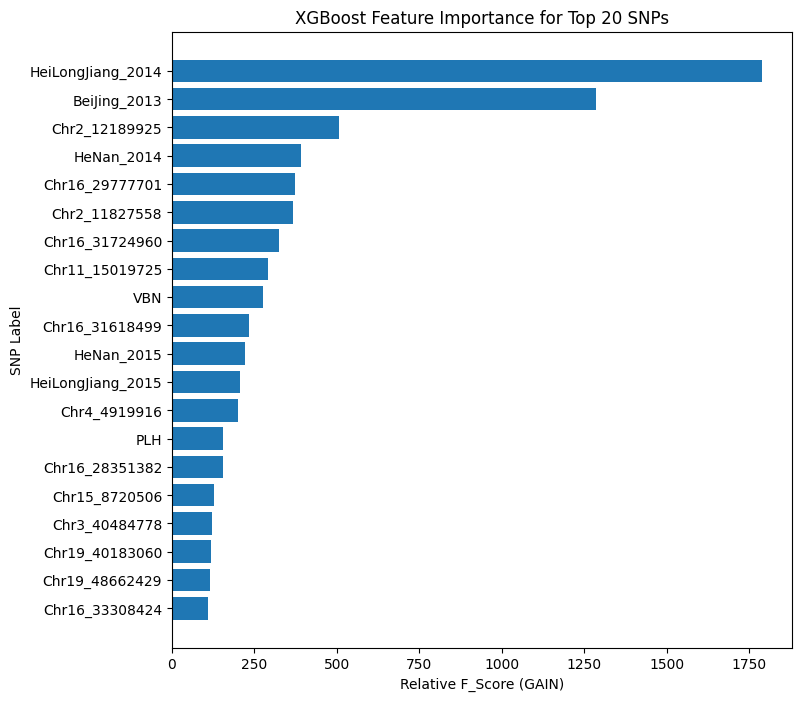

In [60]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20)

In [61]:
explainer = shap.Explainer(best_xgbr_model)

In [62]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

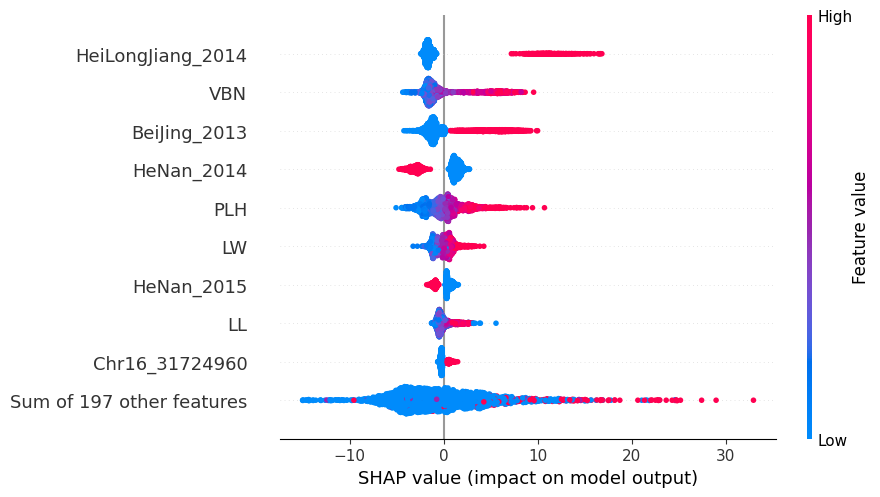

In [63]:
shap.plots.beeswarm(shap_values, show=False)

In [31]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [32]:
holdout_data = holdout_data.set_index('Line')

In [33]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [34]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [35]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [36]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [37]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 206 entries, Chr1_1539926 to landrace
dtypes: float64(4), int64(202)
memory usage: 1.0+ MB


In [38]:
y_holdout.shape

(634, 1)

In [39]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [40]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/enet_allfeats_xgbr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.77
RMSE of Holdout: 6.64
Mean of Holdout: 47.16
This is 14.09% of the mean pheno data
0 45 46.68141
1 39 47.595516
2 62 68.14017
3 47 53.081226
4 42 43.771824


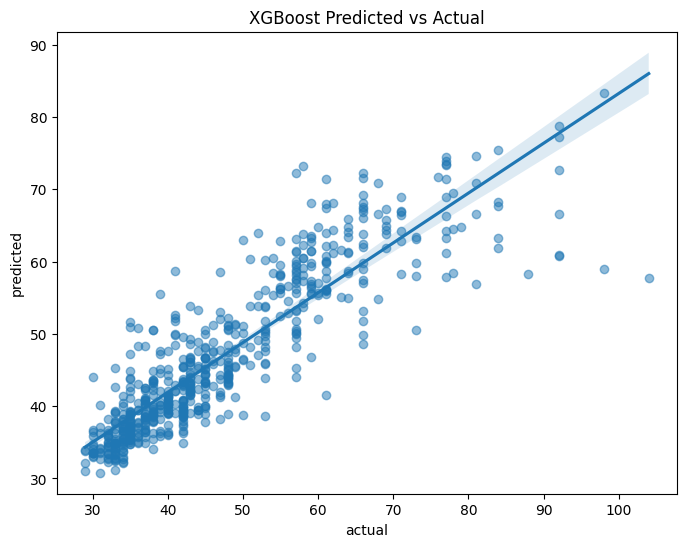

In [41]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [64]:
pickle.dump(best_xgbr_model, open("enet_allfeats_xgbr_bbd.pickle.dat", "wb"))

In [65]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 24), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [66]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.006439226999846115
RMSE for dataset is:7.339842164420454& mean of this fold is 46.21259842519685
this is 15.882773127984285% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3431689164413855
RMSE for dataset is:7.275411028024781& mean of this fold is 47.196850393700785
this is 15.415035044363485% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.015322376532535653
RMSE for dataset is:8.010583555520489& mean of this fold is 46.90157480314961
this is 17.079562017142653% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.16602224514167108
RMSE for dataset is:6.902442747432292& mean of this fold is 44.2992125984252
this is 15.581411818768236% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.2593307402944208
RMSE for 

In [68]:
pickle.dump(best_rfr_model, open("enet_allfeats_rfr_bbd.pickle.dat", "wb"))

In [42]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/enet_allfeats_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.64
RMSE of Holdout: 8.32
Mean of Holdout: 47.16
This is 17.65% of the mean pheno data
0 45 45.492
1 39 49.942
2 62 58.254
3 47 54.616
4 42 44.61


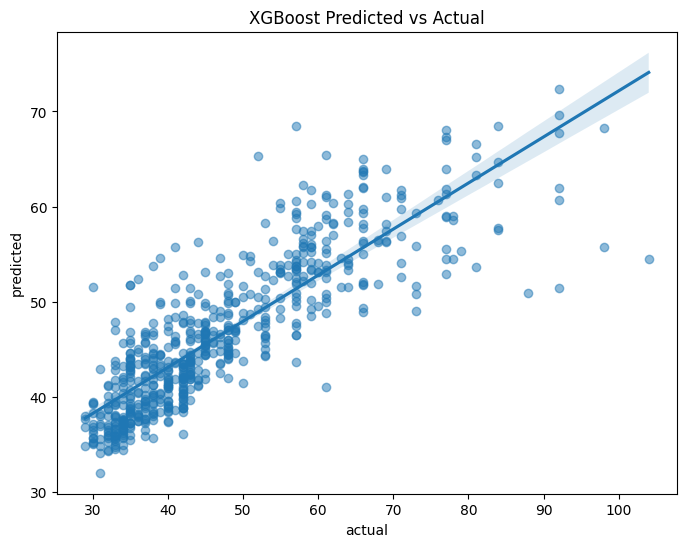

In [43]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [69]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [70]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5583084956138087
RMSE for dataset is:7.197830331684875& mean of this fold is 45.62204724409449
this is 15.777087540973058% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7272048001028544
RMSE for dataset is:5.9660585214648245& mean of this fold is 46.181102362204726
this is 12.91883089899459% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5232562392827682
RMSE for dataset is:7.244322441884488& mean of this fold is 46.732283464566926
this is 15.501751476315583% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5567268727956879
RMSE for dataset is:6.937541116170996& mean of this fold is 46.338582677165356
this is 14.971414133453125% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5707522322517609
RMSE for da

In [72]:
pickle.dump(best_svr_model, open("enet_allfeats_svr_bbd.pickle.dat", "wb"))

In [44]:
best_svr_model = pickle.load(open("../pickle_bestmodels/enet_allfeats_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.71
RMSE of Holdout: 7.50
Mean of Holdout: 47.16
This is 15.89% of the mean pheno data
0 45 47.242426141267856
1 39 49.83029604989031
2 62 67.07863608182095
3 47 54.543803453969645
4 42 44.24837155997818


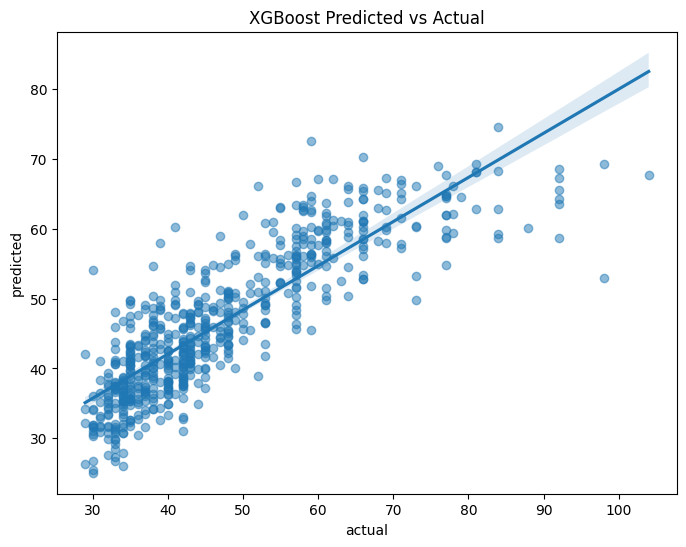

In [45]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only Location

In [46]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr20_42855517,Chr20_42859801,Chr20_42934531,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,0,1,0,0,0,0,1


In [47]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 202 entries, Chr1_1539926 to landrace
dtypes: int64(202)
memory usage: 3.9+ MB


In [48]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr20_42855517,Chr20_42859801,Chr20_42934531,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,0,1,0,0,0,0,1


In [49]:
y_all = fs_data["BBD"].values

In [77]:
# Split training set into training and validation

In [78]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [79]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [80]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6859010244344876), ('colsample_bytree', 0.700874166352458), ('gamma', 2.0829248117745963e-06), ('learning_rate', 0.04039407624792068), ('max_delta_step', 13), ('max_depth', 6), ('min_child_weight', 6), ('n_estimators', 151), ('reg_alpha', 0.0021618359935446346), ('reg_lambda', 3.95392215687309e-09), ('subsample', 0.5540873967709307)])


In [83]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6168228031325084
RMSE for dataset is:6.645451749778074& mean of this fold is 46.37795275590551
this is 14.328902754190414% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6111363067829381
RMSE for dataset is:6.6761401871820185& mean of this fold is 47.1496062992126
this is 14.159482360923786% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5833826393625632
RMSE for dataset is:7.176769460383911& mean of this fold is 47.55118110236221
this is 15.092725972325827% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5230469035832744
RMSE for dataset is:7.365011300390937& mean of this fold is 45.826771653543304
this is 16.071416411505997% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.702729959737009
RMSE for datas

In [52]:
#pickle.dump(best_xgbr_model, open("enet_onlyloc_xgbr_bbd.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/enet_onlyloc_xgbr_bbd.pickle.dat", "rb"))

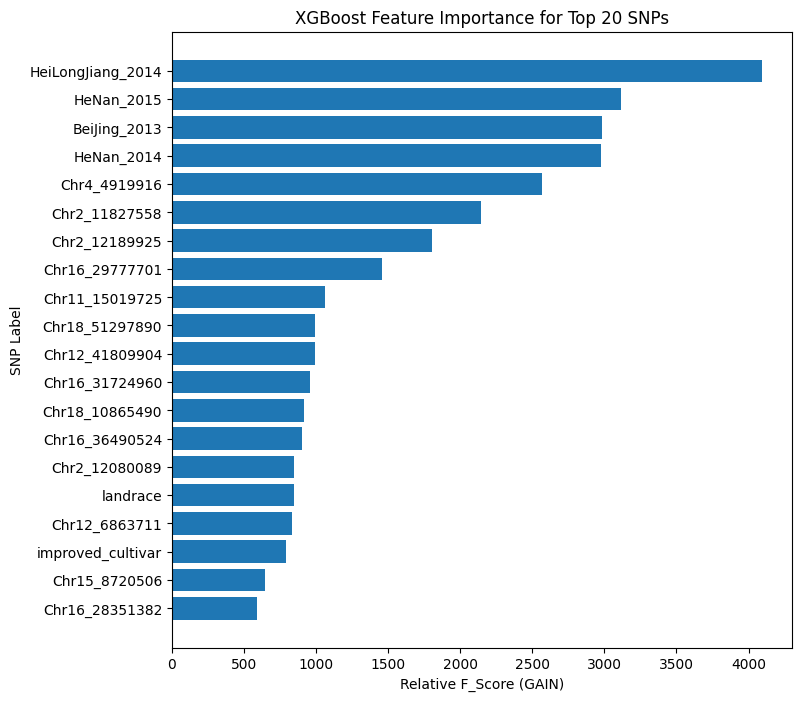

In [86]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20)

In [87]:
explainer = shap.Explainer(best_xgbr_model)

In [88]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

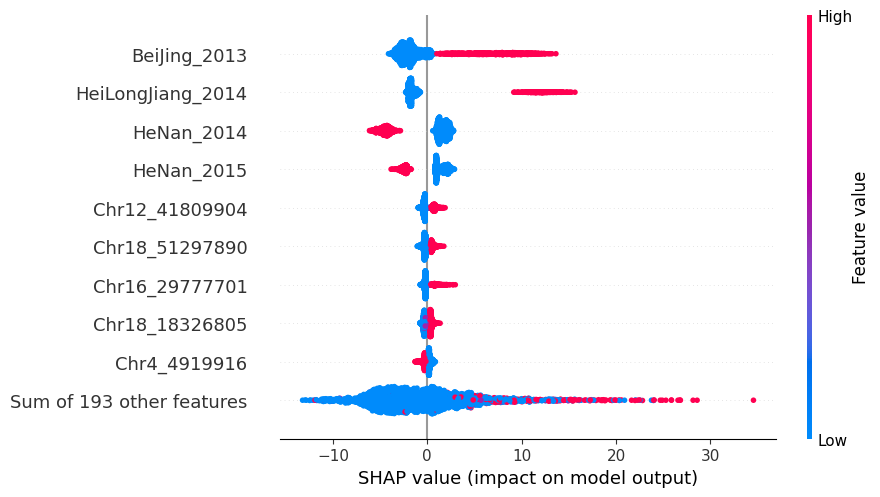

In [89]:
shap.plots.beeswarm(shap_values, show=False)

In [53]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'pickle_files/holdout_data_bbd.pkl'

In [91]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [54]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [55]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [56]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [57]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 202 entries, Chr1_1539926 to landrace
dtypes: int64(202)
memory usage: 1005.5+ KB


In [58]:
X_holdout.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr20_42855517,Chr20_42859801,Chr20_42934531,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,0,0,1,0,0,0,1
s101,2,2,2,0,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s101,2,2,2,0,2,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
s1026,0,2,0,0,2,0,2,0,0,0,...,0,2,2,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,2,2,2,0,1,0,0,0,0,1


In [59]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.75
RMSE of Holdout: 6.96
Mean of Holdout: 47.16
This is 14.77% of the mean pheno data
0 45 45.084625
1 39 46.34144
2 62 63.92793
3 47 49.001976
4 42 43.674904


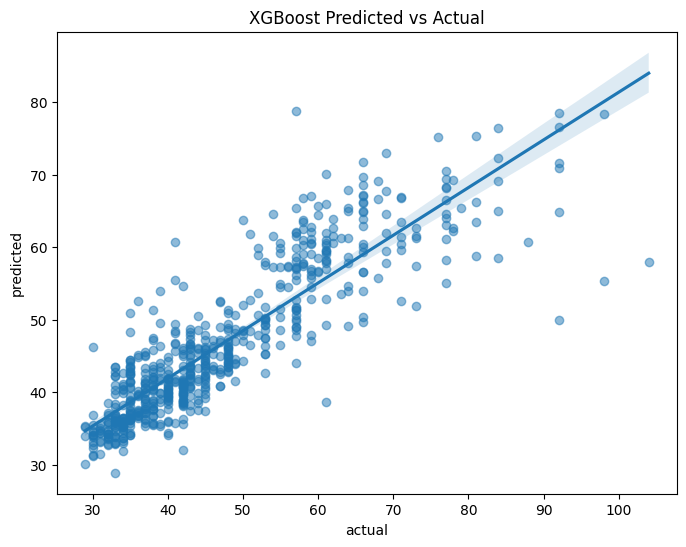

In [60]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [62]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 45 45.084625
1 39 46.34144
2 62 63.92793
3 47 49.001976
4 42 43.674904
5 40 40.976402


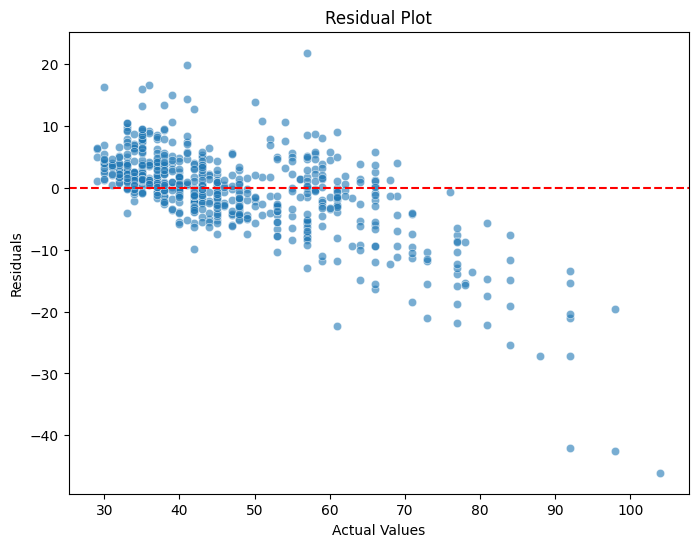

In [63]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [101]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 47), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [102]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.3646667367248597
RMSE for dataset is:8.036881901945431& mean of this fold is 45.074803149606296
this is 17.830098725601708% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.10229501115650197
RMSE for dataset is:8.369864149758156& mean of this fold is 46.63385826771653
this is 17.948041317337037% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4234694606577505
RMSE for dataset is:9.457641322193663& mean of this fold is 47.62204724409449
this is 19.859795765849785% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.09907669342587133
RMSE for dataset is:8.140964642724212& mean of this fold is 46.27165354330709
this is 17.5938485429418% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.19772022458460436
RMSE fo

In [103]:
pickle.dump(best_rfr_model, open("enet_onlyloc_rfr_bbd.pickle.dat", "wb"))

In [64]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/enet_onlyloc_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.55
RMSE of Holdout: 9.30
Mean of Holdout: 47.16
This is 19.72% of the mean pheno data
0 45 48.132
1 39 49.85
2 62 58.5
3 47 55.238
4 42 42.44


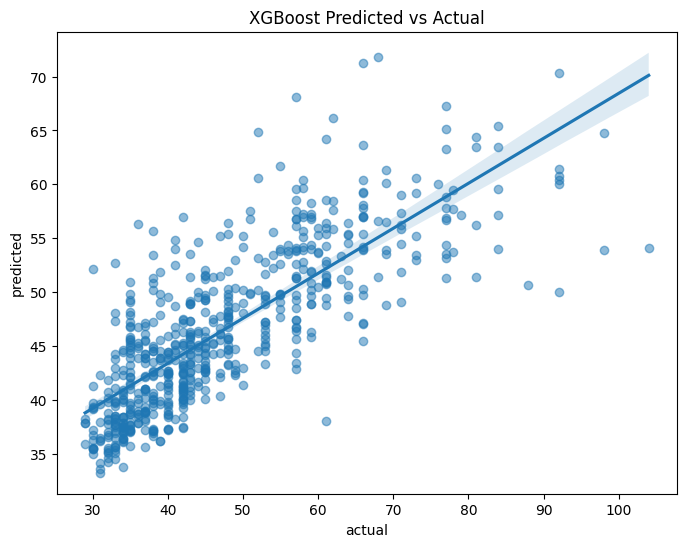

In [65]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [105]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [106]:
best_svr_model = eval_k_fold(best_svreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4315088319471081
RMSE for dataset is:7.9169060317231095& mean of this fold is 46.20472440944882
this is 17.134408078201% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5455584723667871
RMSE for dataset is:7.038198411162982& mean of this fold is 45.85826771653543
this is 15.347719749617081% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3012989591653912
RMSE for dataset is:8.295452423972092& mean of this fold is 45.77165354330709
this is 18.123558538524957% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5571541642506396
RMSE for dataset is:6.86345990487905& mean of this fold is 46.23622047244095
this is 14.844335965933912% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4546407845563244
RMSE for dataset 

In [107]:
pickle.dump(best_svr_model, open("enet_onlyloc_svr_bbd.pickle.dat", "wb"))

In [66]:
best_svr_model = pickle.load(open("../pickle_bestmodels/enet_onlyloc_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.64
RMSE of Holdout: 8.30
Mean of Holdout: 47.16
This is 17.60% of the mean pheno data
0 45 45.090560912893395
1 39 50.79435097790075
2 62 60.792043514043925
3 47 47.98016003608227
4 42 46.26346481611965


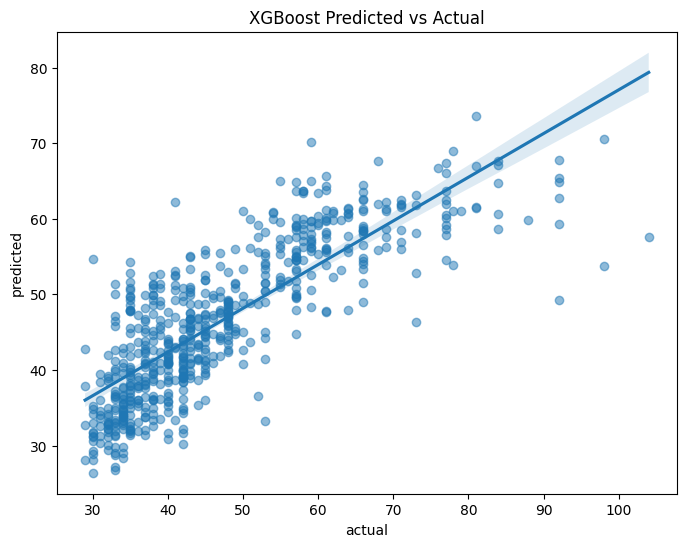

In [67]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only snps

In [68]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 207 entries, Chr1_1539926 to BBD
dtypes: float64(4), int64(203)
memory usage: 4.0+ MB


In [69]:
only_snps = fs_data.iloc[:, 0:195]
only_snps.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr19_48727283,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511,Chr20_42855517,Chr20_42859801,Chr20_42934531
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0


In [70]:
only_snps_dupe = fs_data.iloc[:, 0:195]
only_snps.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr19_48727283,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511,Chr20_42855517,Chr20_42859801,Chr20_42934531
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0


In [71]:
y_all = fs_data["BBD"]
y_all.head()

Line
s100     61
s100     37
s100     43
s1014    77
s1014    42
Name: BBD, dtype: int64

### Run models

In [114]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [115]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [116]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.0924342261681665), ('colsample_bytree', 0.01), ('gamma', 5.778355924525033e-07), ('learning_rate', 0.12606637253276182), ('max_delta_step', 19), ('max_depth', 0), ('min_child_weight', 3), ('n_estimators', 198), ('reg_alpha', 1.0), ('reg_lambda', 8.633520288092824e-05), ('subsample', 1.0)])


In [117]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.663036311033751
RMSE for dataset is:11.090404688901042& mean of this fold is 45.40551181102362
this is 24.425238801533553% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.2374058315365373
RMSE for dataset is:11.796029889849722& mean of this fold is 46.93307086614173
this is 25.13372696939711% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.5466741642002066
RMSE for dataset is:11.438007305343804& mean of this fold is 47.0
this is 24.336185756050646% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.8119710297902145
RMSE for dataset is:10.994616940947047& mean of this fold is 45.27165354330709
this is 24.28587444995695% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.04115829317787
RMSE for dataset is:11.

In [118]:
pickle.dump(best_xgbr_model, open("enet_onlysnps_xgbr_bbd.pickle.dat", "wb"))

In [72]:
best_xgbr_model=pickle.load(open("../pickle_bestmodels/enet_onlysnps_xgbr_bbd.pickle.dat", "rb"))

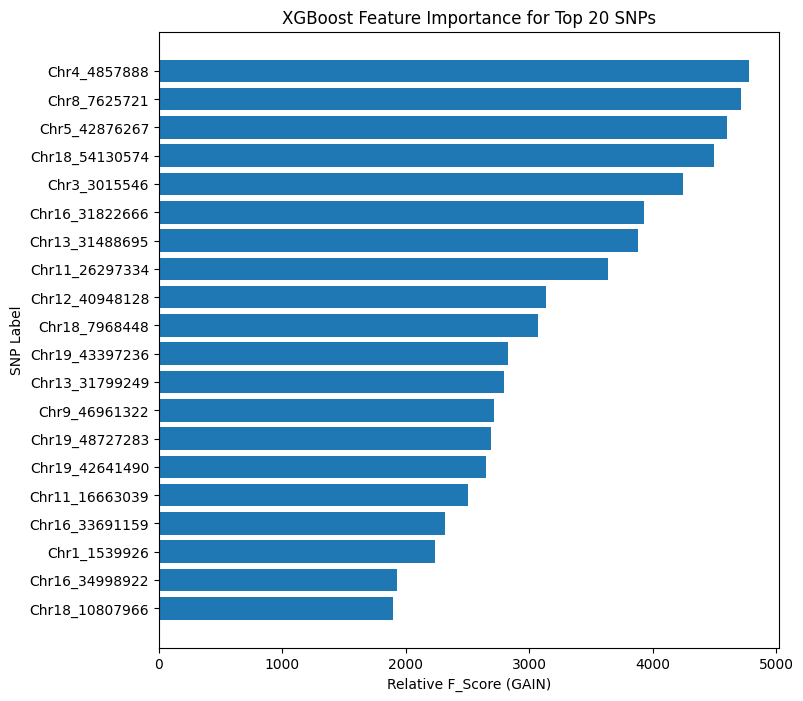

In [119]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20)

In [120]:
explainer = shap.Explainer(best_xgbr_model)

In [121]:
shap_values = explainer(only_snps_dupe)

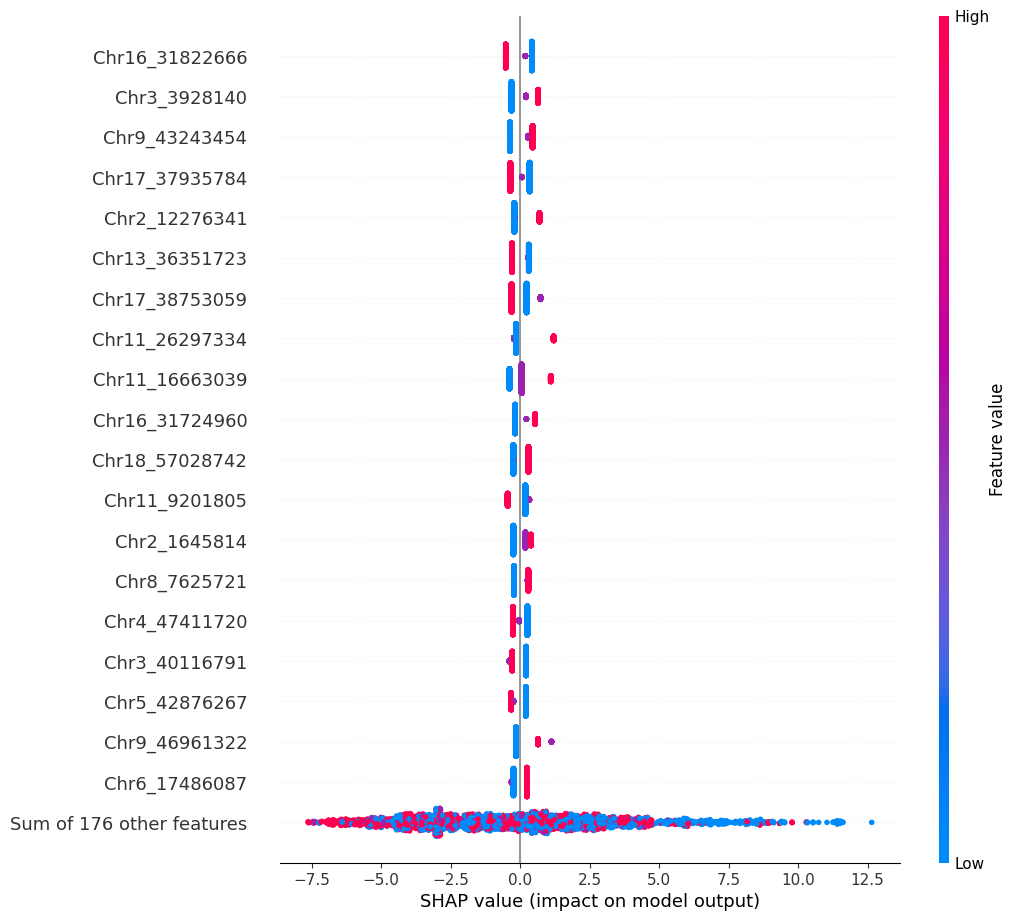

In [122]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])

In [123]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [124]:
holdout_data = holdout_data.set_index('Line')

In [73]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [74]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [75]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [76]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 195 entries, Chr1_1539926 to Chr20_42934531
dtypes: int64(195)
memory usage: 970.8+ KB


In [77]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.12
RMSE of Holdout: 13.00
Mean of Holdout: 47.16
This is 27.57% of the mean pheno data
0 45 49.054882
1 39 46.96279
2 62 46.96279
3 47 46.49159
4 42 47.857548


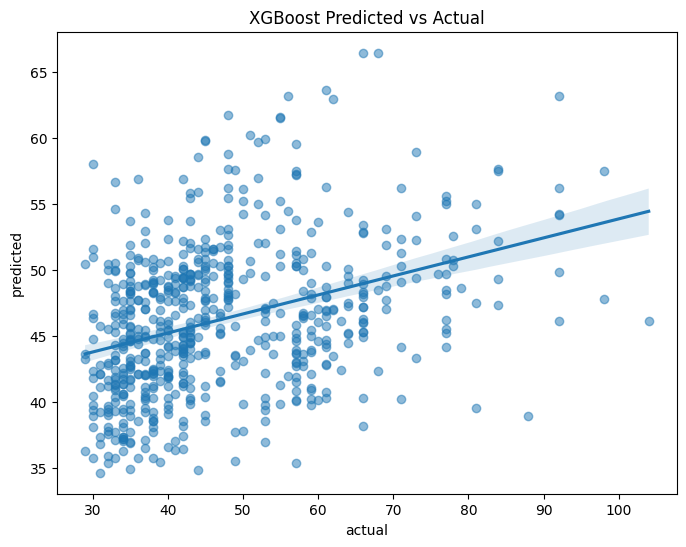

In [78]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [131]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 2), ('n_estimators', 500)])


In [132]:
best_rfr_model = eval_k_fold(best_rfreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.580510124494768
RMSE for dataset is:12.015024646239311& mean of this fold is 46.38582677165354
this is 25.90236173947365% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.462593697537158
RMSE for dataset is:11.124343354942752& mean of this fold is 45.63385826771653
this is 24.377389458678795% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.332256895253016
RMSE for dataset is:12.173327858395997& mean of this fold is 45.50787401574803
this is 26.749937503526112% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.10791391270301
RMSE for dataset is:11.469078353888698& mean of this fold is 45.92913385826772
this is 24.97124894469166% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.287359192526841
RMSE for data

In [133]:
pickle.dump(best_rfr_model, open("enet_onlysnps_rfr_bbd.pickle.dat", "wb"))

In [79]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/enet_onlysnps_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.11
RMSE of Holdout: 13.07
Mean of Holdout: 47.16
This is 27.71% of the mean pheno data
0 45 50.75160081383369
1 39 45.584506683324236
2 62 45.584506683324236
3 47 47.65810291759286
4 42 47.311306007163566


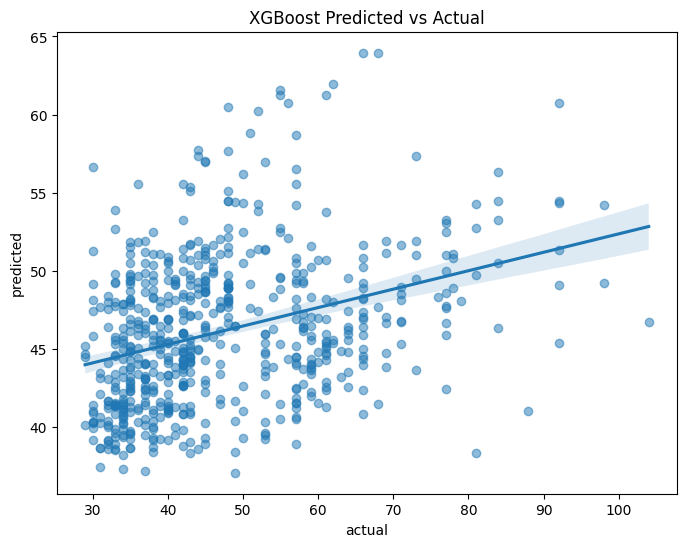

In [80]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [135]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'sigmoid')])


In [136]:
best_svr_model = eval_k_fold(best_svreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.7109336663076276
RMSE for dataset is:11.81030887253876& mean of this fold is 45.23622047244095
this is 26.108080536334594% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.71242291764496
RMSE for dataset is:10.680596631846312& mean of this fold is 44.42913385826772
this is 24.039623788116643% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.51506125868906
RMSE for dataset is:13.004135031011181& mean of this fold is 47.59842519685039
this is 27.320515284341106% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.334561289291521
RMSE for dataset is:12.004830000715232& mean of this fold is 47.12204724409449
this is 25.476036596053714% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.071133029507159
RMSE for dat

In [137]:
pickle.dump(best_svr_model, open("enet_onlysnps_svr_bbd.pickle.dat", "wb"))

In [81]:
best_svr_model = pickle.load(open("../pickle_bestmodels/enet_onlysnps_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.05
RMSE of Holdout: 13.55
Mean of Holdout: 47.16
This is 28.73% of the mean pheno data
0 45 45.27185384961996
1 39 45.17031988397052
2 62 45.17031988397052
3 47 43.26788556618894
4 42 45.46322484056077


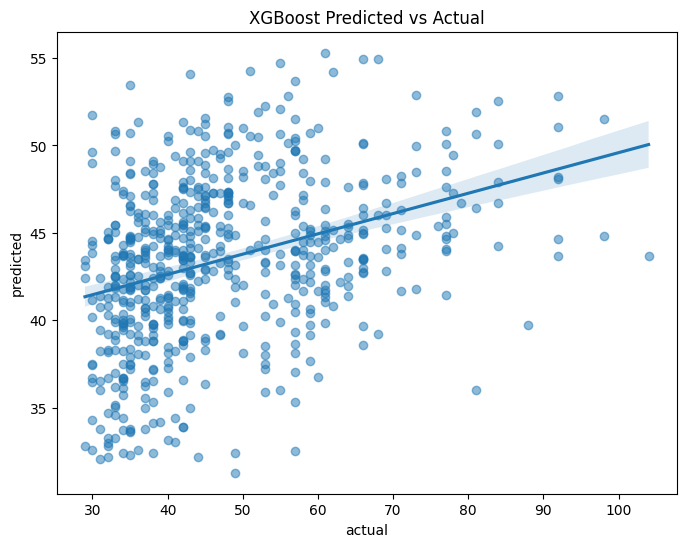

In [82]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)